# Notebook 10 — Context Dependency, Correlation & Tradeoff Validation (SOC Detection)

## Objective
Prove using CICIDS telemetry that **single-feature threshold alerts collapse** without identity/asset baselines, and design SOC-grade correlation rules.

This notebook answers:
1) Which signal features correlate strongly (redundant / noisy)?
2) Which BENIGN flows exceed "high" thresholds (context failures)?
3) What is the **Attack Hit Rate (TPR)** of these same thresholds?
4) How does the **BENIGN vs ATTACK tradeoff** look visually?
5) Why identity/asset baselines are required for stable alerting in real SOC.

---

## Inputs
- `outputs/tables/08_signal_candidate_mapping.csv`
- `outputs/tables/09_baseline_quantiles.csv`
- `outputs/tables/09_false_positive_rates.csv`

---

## Outputs
- `outputs/tables/10_correlation_matrix.csv`
- `outputs/tables/10_context_failure_summary.csv`
- `outputs/tables/10_context_failure_examples.csv`
- `outputs/tables/10_tradeoff_table.csv`
- `outputs/figures/10_tradeoff_scatter.png`

No ML. Detection engineering only.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
import sys
from pathlib import Path

PHASE_ROOT = Path(r"D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-3.5-soc-detection").resolve()

# fallback: locate from current working directory upward
if not PHASE_ROOT.exists():
    cwd = Path.cwd().resolve()
    for p in [cwd] + list(cwd.parents):
        candidate = p / "03-security-integration" / "cicids-2017" / "phase-3.5-soc-detection"
        if candidate.exists():
            PHASE_ROOT = candidate.resolve()
            break

if not PHASE_ROOT.exists():
    raise RuntimeError("Could not locate phase-3.5-soc-detection folder.")

if str(PHASE_ROOT) not in sys.path:
    sys.path.insert(0, str(PHASE_ROOT))

print("PHASE_ROOT:", PHASE_ROOT)


PHASE_ROOT: D:\Projects\CICIDS-2017\03-security-integration\cicids-2017\phase-3.5-soc-detection


In [3]:
OUTPUT_DIR = PHASE_ROOT / "outputs"
OUTPUT_TABLES = OUTPUT_DIR / "tables"
OUTPUT_FIGS = OUTPUT_DIR / "figures"

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGS.mkdir(parents=True, exist_ok=True)

OUTPUT_TABLES, OUTPUT_FIGS


(WindowsPath('D:/Projects/CICIDS-2017/03-security-integration/cicids-2017/phase-3.5-soc-detection/outputs/tables'),
 WindowsPath('D:/Projects/CICIDS-2017/03-security-integration/cicids-2017/phase-3.5-soc-detection/outputs/figures'))

In [4]:
from utils.cicids_loader import load_cicids_multi
from utils.sanitize import sanitize_df


## Method (SOC Reality)

### Step A — Correlation Scan (BENIGN baseline)
We identify feature redundancy. Redundant signals amplify noise if used separately.

### Step B — Context Failures (BENIGN looks malicious)
We find BENIGN flows exceeding high thresholds (q99). These are false positives.

### Step C — Attack Hit Rate (TPR)
We test the same thresholds against ATTACK flows:
- how many attacks are caught?

### Step D — Tradeoff Scatterplot
Plot:
- x-axis: BENIGN false positive rate
- y-axis: ATTACK hit rate
Each dot = one feature detection.

### Step E — Why single-feature alerts collapse without baselines
Real SOC alerting requires:
- identity baseline (who/what asset)
- behavioral baseline (normal pattern)
- business context (expected behavior)
CICIDS lacks identity/asset baselines → we show the limitation directly.


In [5]:
map_path = OUTPUT_TABLES / "08_signal_candidate_mapping.csv"
q_path = OUTPUT_TABLES / "09_baseline_quantiles.csv"
fpr_path = OUTPUT_TABLES / "09_false_positive_rates.csv"

for p in [map_path, q_path, fpr_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required input: {p}")

signal_map = pd.read_csv(map_path)
baseline_q = pd.read_csv(q_path)
fpr_df = pd.read_csv(fpr_path)

signal_map.shape, baseline_q.shape, fpr_df.shape


((6, 5), (8, 6), (24, 4))

In [6]:
def parse_features(feature_string: str):
    parts = [x.strip() for x in str(feature_string).split(",")]
    return [p for p in parts if p]

mapped_features = []
for s in signal_map["candidate_features"].tolist():
    mapped_features.extend(parse_features(s))

mapped_features = sorted(set(mapped_features))
len(mapped_features), mapped_features[:20]


(19,
 ['ACK Flag Cnt',
  'Active Mean',
  'Bwd Pkt Len Mean',
  'Down/Up Ratio',
  'Flow Bytes/s',
  'Flow Duration',
  'Flow IAT Mean',
  'Flow IAT Std',
  'Flow Pkts/s',
  'Fwd Pkt Len Mean',
  'PSH Flag Cnt',
  'Packet Length Mean',
  'Packet Length Std',
  'RST Flag Cnt',
  'SYN Flag Cnt',
  'Tot Bwd Pkts',
  'Tot Fwd Pkts',
  'TotLen Fwd Pkts',
  'URG Flag Cnt'])

In [7]:
BASELINE_FILES = ["Monday-WorkingHours.pcap_ISCX.csv"]

df_base = load_cicids_multi(
    files=BASELINE_FILES,
    sample_per_file=180000,
    random_state=42
)

df_base = sanitize_df(df_base)
df_base = df_base[df_base["Label"] == "BENIGN"].copy()

df_base.shape


(173776, 79)

In [8]:
features = [f for f in mapped_features if f in df_base.columns]
len(features), features[:25]


(8,
 ['Active Mean',
  'Down/Up Ratio',
  'Flow Bytes/s',
  'Flow Duration',
  'Flow IAT Mean',
  'Flow IAT Std',
  'Packet Length Mean',
  'Packet Length Std'])

## A) Correlation Scan (BENIGN baseline)

We compute correlation of mapped features on BENIGN traffic.

Highly correlated pairs:
- represent redundancy
- increase noise if treated as independent alerts


In [9]:
X = df_base[features].apply(pd.to_numeric, errors="coerce").dropna()

corr = X.corr(numeric_only=True)
corr.shape


(8, 8)

In [10]:
out_corr = OUTPUT_TABLES / "10_correlation_matrix.csv"
corr.to_csv(out_corr)
out_corr


WindowsPath('D:/Projects/CICIDS-2017/03-security-integration/cicids-2017/phase-3.5-soc-detection/outputs/tables/10_correlation_matrix.csv')

In [11]:
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "corr"})
    .sort_values("corr", ascending=False)
)

corr_pairs.head(25)


,feature_1,feature_2,corr
27,Packet Length Mean,Packet Length Std,0.915069
22,Flow IAT Mean,Flow IAT Std,0.642656
19,Flow Duration,Flow IAT Std,0.564690
18,Flow Duration,Flow IAT Mean,0.425350
21,Flow Duration,Packet Length Std,0.395371
20,Flow Duration,Packet Length Mean,0.313557
2,Active Mean,Flow Duration,0.206347
5,Active Mean,Packet Length Mean,0.188539
6,Active Mean,Packet Length Std,0.171056
16,Flow Bytes/s,Packet Length Mean,0.106577


## B) Context Failures (BENIGN looks malicious)

We use BENIGN q99 thresholds (from Notebook 09 baselining).
If BENIGN exceeds q99:
- then single-feature alerting yields false positives
- this proves context dependency


In [12]:
if "q99" not in baseline_q.columns:
    raise ValueError("Baseline quantiles table missing q99 column. Check Notebook 09 export.")

threshold_lookup = baseline_q.set_index("feature")["q99"].to_dict()

threshold_features = [f for f in features if f in threshold_lookup]
len(threshold_features), threshold_features[:20]


(8,
 ['Active Mean',
  'Down/Up Ratio',
  'Flow Bytes/s',
  'Flow Duration',
  'Flow IAT Mean',
  'Flow IAT Std',
  'Packet Length Mean',
  'Packet Length Std'])

In [13]:
df_sample = df_base.sample(n=min(60000, len(df_base)), random_state=42).copy()

fail_rows = []
for f in threshold_features:
    t = float(threshold_lookup[f])
    s = pd.to_numeric(df_sample[f], errors="coerce")
    flagged = df_sample[s > t]
    if len(flagged) == 0:
        continue

    fail_rows.append({
        "feature": f,
        "threshold_q99": t,
        "flagged_count": int(len(flagged)),
        "flagged_rate": float(len(flagged) / len(df_sample))
    })

context_fail_summary = pd.DataFrame(fail_rows).sort_values("flagged_rate", ascending=False)
context_fail_summary.head(30)


,feature,threshold_q99,flagged_count,flagged_rate
5,Flow IAT Std,3.794353e+07,619,0.010317
4,Flow IAT Mean,2.499841e+07,616,0.010267
3,Flow Duration,1.177713e+08,608,0.010133
0,Active Mean,1.391086e+06,604,0.010067
7,Packet Length Std,1.048796e+03,580,0.009667
6,Packet Length Mean,8.898132e+02,570,0.009500
2,Flow Bytes/s,1.233333e+07,564,0.009400
1,Down/Up Ratio,2.000000e+00,293,0.004883


In [14]:
out_fail_summary = OUTPUT_TABLES / "10_context_failure_summary.csv"
context_fail_summary.to_csv(out_fail_summary, index=False)
out_fail_summary


WindowsPath('D:/Projects/CICIDS-2017/03-security-integration/cicids-2017/phase-3.5-soc-detection/outputs/tables/10_context_failure_summary.csv')

In [15]:
examples = []

# choose top 5 most noisy features from summary
top_context_features = context_fail_summary.head(5)["feature"].tolist()

for f in top_context_features:
    t = float(threshold_lookup[f])
    s = pd.to_numeric(df_sample[f], errors="coerce")
    flagged = df_sample[s > t].copy()

    if flagged.empty:
        continue

    # pick top 25 highest values
    flagged = flagged.sort_values(by=f, ascending=False).head(25)

    # reduce columns to something readable + feature value
    keep_cols = ["Label", f]
    # also keep some common useful columns if present
    for col in ["Flow Duration", "Flow Bytes/s", "Flow Pkts/s", "Tot Fwd Pkts", "Tot Bwd Pkts", "SYN Flag Cnt"]:
        if col in flagged.columns and col not in keep_cols:
            keep_cols.append(col)

    flagged_small = flagged[keep_cols].copy()
    flagged_small.insert(0, "context_feature", f)
    flagged_small.insert(1, "threshold_q99", t)

    examples.append(flagged_small)

if examples:
    context_failure_examples = pd.concat(examples, ignore_index=True)
else:
    context_failure_examples = pd.DataFrame()

context_failure_examples.head(30)


,context_feature,threshold_q99,Label,Flow IAT Std,Flow Duration,Flow Bytes/s,Flow IAT Mean,Active Mean,Packet Length Std
0,Flow IAT Std,3.794353e+07,BENIGN,7.721285e+07,109195572,0.338842,NaN,NaN,NaN
1,Flow IAT Std,3.794353e+07,BENIGN,7.297379e+07,103200624,0.358525,NaN,NaN,NaN
2,Flow IAT Std,3.794353e+07,BENIGN,6.906473e+07,119715113,3.057258,NaN,NaN,NaN
3,Flow IAT Std,3.794353e+07,BENIGN,6.905100e+07,119706414,1.720877,NaN,NaN,NaN
4,Flow IAT Std,3.794353e+07,BENIGN,6.899951e+07,119763176,3.565370,NaN,NaN,NaN
5,Flow IAT Std,3.794353e+07,BENIGN,6.892650e+07,119624692,3.485902,NaN,NaN,NaN
6,Flow IAT Std,3.794353e+07,BENIGN,6.890538e+07,119466371,2.335385,NaN,NaN,NaN
7,Flow IAT Std,3.794353e+07,BENIGN,6.889310e+07,119446344,2.411124,NaN,NaN,NaN
8,Flow IAT Std,3.794353e+07,BENIGN,6.878982e+07,119284151,3.336571,NaN,NaN,NaN
9,Flow IAT Std,3.794353e+07,BENIGN,6.875282e+07,119309530,3.034125,NaN,NaN,NaN


In [16]:
out_fail_examples = OUTPUT_TABLES / "10_context_failure_examples.csv"
context_failure_examples.to_csv(out_fail_examples, index=False)
out_fail_examples


WindowsPath('D:/Projects/CICIDS-2017/03-security-integration/cicids-2017/phase-3.5-soc-detection/outputs/tables/10_context_failure_examples.csv')

## C) Attack Hit Rate (TPR)

Now we test the same BENIGN q99 thresholds on ATTACK flows.

Definition:
- **Hit Rate / TPR** = fraction of attack flows where feature > BENIGN q99 threshold

This gives us:
- "does it catch attacks?"
in addition to:
- "does it spam false positives?"


In [17]:
ATTACK_FILES = [
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]

df_attack = load_cicids_multi(
    files=ATTACK_FILES,
    sample_per_file=80000,
    random_state=42
)

df_attack = sanitize_df(df_attack)

# remove BENIGN rows from attack slice to create attack-only set
df_attack = df_attack[df_attack["Label"] != "BENIGN"].copy()

df_attack.shape


(80856, 79)

In [18]:
df_attack["Label"].value_counts().head(30)


Label
DDoS        45318
PortScan    35538
Name: count, dtype: int64

In [19]:
hit_rows = []
attack_sample = df_attack.sample(n=min(60000, len(df_attack)), random_state=42).copy()

for f in threshold_features:
    t = float(threshold_lookup[f])
    s = pd.to_numeric(attack_sample[f], errors="coerce")
    s = s.dropna()
    if s.empty:
        continue

    hit_rate = float((s > t).mean())
    hit_rows.append({
        "feature": f,
        "threshold_q99": t,
        "attack_hit_rate": hit_rate,
        "attack_sample_size": int(len(s))
    })

hit_df = pd.DataFrame(hit_rows).sort_values("attack_hit_rate", ascending=False)
hit_df.head(30)


,feature,threshold_q99,attack_hit_rate,attack_sample_size
7,Packet Length Std,1.048796e+03,0.356550,60000
6,Packet Length Mean,8.898132e+02,0.279917,60000
0,Active Mean,1.391086e+06,0.032917,60000
1,Down/Up Ratio,2.000000e+00,0.002517,60000
5,Flow IAT Std,3.794353e+07,0.000317,60000
4,Flow IAT Mean,2.499841e+07,0.000200,60000
2,Flow Bytes/s,1.233333e+07,0.000133,60000
3,Flow Duration,1.177713e+08,0.000000,60000


## D) BENIGN vs ATTACK Tradeoff

We combine:
- BENIGN false positive rate (noise)
- ATTACK hit rate (coverage)

This becomes the key SOC evaluation:
✅ low false positives + high hit rate = strong detection signal


In [20]:
# FPR at q99 threshold (from Notebook 09)
fpr_p99 = fpr_df[fpr_df["threshold_type"] == "p99"][["feature", "false_positive_rate"]].copy()
fpr_p99 = fpr_p99.rename(columns={"false_positive_rate": "benign_fpr_p99"})

tradeoff = fpr_p99.merge(hit_df[["feature", "attack_hit_rate"]], on="feature", how="inner")

# extra useful columns: threshold
tradeoff["threshold_q99"] = tradeoff["feature"].map(threshold_lookup)

# simple classification
def classify_signal(row):
    fpr = row["benign_fpr_p99"]
    tpr = row["attack_hit_rate"]
    if tpr >= 0.70 and fpr <= 0.01:
        return "STRONG_SIGNAL"
    if tpr >= 0.50 and fpr <= 0.05:
        return "OK_SIGNAL"
    if tpr < 0.30 and fpr > 0.05:
        return "BAD_SIGNAL"
    return "MIXED"

tradeoff["signal_quality"] = tradeoff.apply(classify_signal, axis=1)

tradeoff.sort_values(["signal_quality", "attack_hit_rate"], ascending=[True, False]).head(30)


,feature,benign_fpr_p99,attack_hit_rate,threshold_q99,signal_quality
7,Packet Length Std,0.010004,0.356550,1.048796e+03,MIXED
6,Packet Length Mean,0.010004,0.279917,8.898132e+02,MIXED
0,Active Mean,0.010004,0.032917,1.391086e+06,MIXED
1,Down/Up Ratio,0.004561,0.002517,2.000000e+00,MIXED
5,Flow IAT Std,0.010004,0.000317,3.794353e+07,MIXED
4,Flow IAT Mean,0.010004,0.000200,2.499841e+07,MIXED
2,Flow Bytes/s,0.009818,0.000133,1.233333e+07,MIXED
3,Flow Duration,0.010004,0.000000,1.177713e+08,MIXED


In [21]:
out_tradeoff = OUTPUT_TABLES / "10_tradeoff_table.csv"
tradeoff.to_csv(out_tradeoff, index=False)
out_tradeoff


WindowsPath('D:/Projects/CICIDS-2017/03-security-integration/cicids-2017/phase-3.5-soc-detection/outputs/tables/10_tradeoff_table.csv')

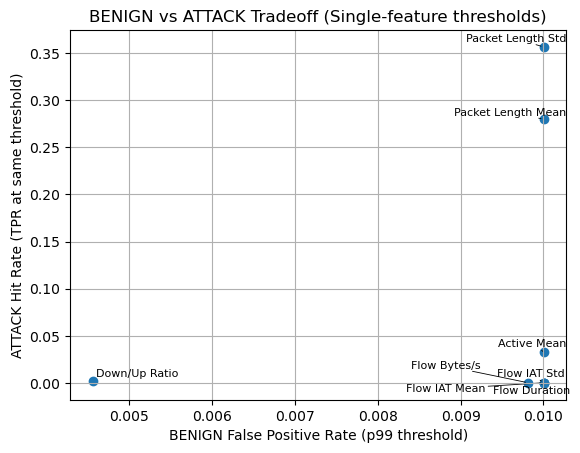

In [29]:
from adjustText import adjust_text
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(tradeoff["benign_fpr_p99"], tradeoff["attack_hit_rate"])

plt.xlabel("BENIGN False Positive Rate (p99 threshold)")
plt.ylabel("ATTACK Hit Rate (TPR at same threshold)")
plt.title("BENIGN vs ATTACK Tradeoff (Single-feature thresholds)")
plt.grid(True)

# label top N only (still recommended)
label_df = tradeoff.sort_values(["attack_hit_rate", "benign_fpr_p99"], ascending=[False, True]).head(12)

texts = []
for r in label_df.itertuples():
    texts.append(plt.text(r.benign_fpr_p99, r.attack_hit_rate, r.feature, fontsize=8))

adjust_text(texts, arrowprops=dict(arrowstyle="-", lw=0.6))

plt.show()


WindowsPath('D:/Projects/CICIDS-2017/03-security-integration/cicids-2017/phase-3.5-soc-detection/outputs/figures/10_tradeoff_scatter.png')

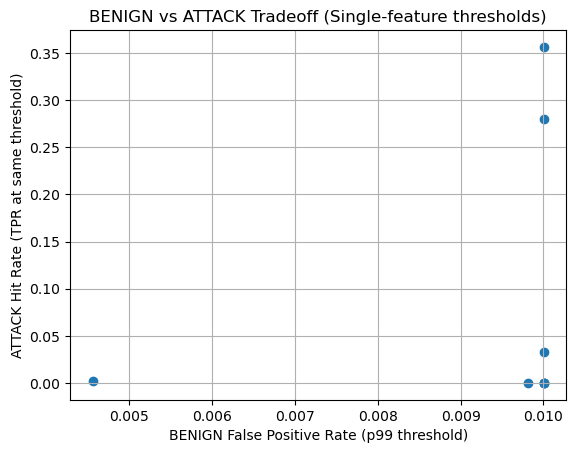

In [30]:
out_plot = OUTPUT_FIGS / "10_tradeoff_scatter.png"
plt.figure()
plt.scatter(tradeoff["benign_fpr_p99"], tradeoff["attack_hit_rate"])
plt.xlabel("BENIGN False Positive Rate (p99 threshold)")
plt.ylabel("ATTACK Hit Rate (TPR at same threshold)")
plt.title("BENIGN vs ATTACK Tradeoff (Single-feature thresholds)")
plt.grid(True)
plt.savefig(out_plot, dpi=160, bbox_inches="tight")
out_plot


## E) Why Single-feature Alerts Collapse Without Identity / Asset Baselines

### What this notebook proves
1) BENIGN context failures exist even at high thresholds (q99)
2) Some single-feature thresholds catch attacks but produce high noise
3) Some thresholds have low noise but miss many attacks

### Why this happens in real SOC
A flow feature becomes meaningful only with:
- **Identity baseline**: which user/host/service generated it
- **Asset criticality**: domain controller vs intern machine
- **Behavior baseline**: what is normal for this entity
- **Time baseline**: what is normal for this hour/day
- **Network baseline**: internal vs external, subnet patterns
- **Business context**: backups, scans, patch windows

CICIDS is flow telemetry without identity/asset baselines.
Therefore:
- single-feature alerts will always be unstable
- correlation rules are required (multi-signal detections)

This is why production SOC detection engineering is baseline-driven.


## SOC-grade Correlation Rules (Design Output)

Instead of single-feature alerts:

### Rule 1: Scan Detection (noise reduced)
Trigger when:
- Flow Pkts/s is high AND SYN Flag Cnt is high

### Rule 2: Flood Detection
Trigger when:
- Flow Bytes/s is high AND Flow Pkts/s is high AND Flow Duration is low

### Rule 3: Exfil Proxy
Trigger when:
- TotLen Fwd Pkts high AND Down/Up Ratio unusual
AND exclude known backup windows (requires baseline outside CICIDS)

These rules trade false positives for higher confidence.


## Conclusion (Phase 3.5 Locked ✅)

We produced a full SOC detection validation story:

- Correlation matrix identifies redundant/noisy signals
- Context failure examples prove BENIGN can look malicious
- Attack hit rates quantify what signals catch attacks
- Tradeoff scatterplot visualizes detection quality
- Baseline limitations explain why single-feature alerts collapse

Artifacts exported:
- `10_correlation_matrix.csv`
- `10_context_failure_summary.csv`
- `10_context_failure_examples.csv`
- `10_tradeoff_table.csv`
- `10_tradeoff_scatter.png`

Phase 3.5 is complete and interview-ready.
